# Train a GNN directly to predict torsion energies

**Note: this is an *experimental* notebook only to demonstrate a proof-of-concept.
While some parts of this notebook may eventually be fully supported by OpenFF-NAGL, the general conclusion arrived at is that it is likely easiest to work at this solution outside of the NAGL framework.**

To execute this example fully, the following packages are required.

* openff-nagl
* openff-recharge
* openff-qcsubmit
* psi4

However, if you wish to just follow along the training part without first creating the training datasets yourself, you can get away with just `openff-nagl` installed and simply load the training/validation data from the provided `.parquet` files. The commands are provided at the end of the "Generate and format training data" section, but commented out.

## Current status
- [x] Verified that c_ij coefficients are calculated via pooling (see https://github.com/openforcefield/openff-nagl/pull/163)
- [x] Test geometry functions (see alpha_test.py)
- [ ] Verify alpha for a test set (biaryl?)
- [ ] Modify NAGL output to a scalar
- [ ] Train with a QCarchive dataset
- [ ] Train with a larger and more diverse dataset

In [1]:
import collections
import tqdm

from qcportal import PortalClient
from openff.units import unit

from openff.toolkit import Molecule, ForceField
from openff.qcsubmit.results import BasicResultCollection
from openff.recharge.esp.storage import MoleculeESPRecord
from openff.recharge.esp.qcresults import from_qcportal_results
from openff.recharge.grids import MSKGridSettings
from openff.recharge.utilities.geometry import compute_vector_field

import pyarrow as pa
import pyarrow.parquet as pq
import numpy as np

import torch
import MDAnalysis as mda

## Generate and format training data


### Downloading from QCArchive
First, we will create training data. We'll download a smaller training set for the purposes of this example.

In [2]:
# qc_client = PortalClient("https://api.qcarchive.molssi.org:443", cache_dir=".")

# # download dataset from QCPortal
# br_esps_collection = BasicResultCollection.from_server(
#     client=qc_client,
#     datasets="OpenFF multi-Br ESP Fragment Conformers v1.1",
#     spec_name="HF/6-31G*",
# )

# records_and_molecules = br_esps_collection.to_records()

### Convert to PyArrow dataset

NAGL reads in and trains to data from [PyArrow tables](https://arrow.apache.org/docs/python/getstarted.html#creating-arrays-and-tables). Below we create some easy data by using an existing force field to assign torsion energies to each individual torsion, which then gets summed over the central bond.

*Note: the maths could probably use double-checking.*

In [3]:
def calc_torsion_energy(angle, parameter):
    angle = (angle * unit.degrees).m_as(unit.radians)
    total = 0 * unit.kilojoules_per_mole
    for k, phase, periodicity in zip(parameter.k, parameter.phase, parameter.periodicity):
        phase = phase.m_as(unit.radians)
        subtotal = k * (1 + np.cos(periodicity * angle - phase))
        total += subtotal
    return total


def get_central_bond_torsions(mol, forcefield):
    labels = forcefield.label_molecules(mol.to_topology())[0]["ProperTorsions"]
    u = mda.Universe(mol.to_rdkit())

    bonds_to_dihedrals = collections.defaultdict(list)
    for key in labels:
        center = tuple(sorted(key[1:3]))
        bonds_to_dihedrals[center].append(key)

    # sort bonds...
    energies = []
    keys = sorted([
        tuple(sorted([bond.atom1_index, bond.atom2_index]))
        for bond in mol.bonds
    ])
    for key in keys:
        dihedrals = bonds_to_dihedrals[key]
        
        energy = 0 * unit.kilojoules_per_mole
        for dihedral_indices in dihedrals:
            dihedral_parameter = labels[dihedral_indices]
            angle = u.atoms[list(dihedral_indices)].dihedral.value()
            energy += calc_torsion_energy(angle, dihedral_parameter)

        energies.append(energy.m_as(unit.kilojoules_per_mole))
    return energies

In [4]:
pyarrow_entries = []
forcefield = ForceField("openff-2.1.0.offxml")
# for record, molecule in tqdm.tqdm(records_and_molecules):
#     central_torsion_energies = get_central_bond_torsions(molecule, forcefield)
#     entry = {
#         # hopefully this preserves bond order
#         "mapped_smiles": molecule.to_smiles(mapped=True),
#         "torsion_energies": central_torsion_energies,
#         "conformer": molecule.conformers[0].m_as(unit.angstrom).flatten().tolist(),
#     }
#     pyarrow_entries.append(entry)


# # arbitrarily split into training and validation datasets
# training_pyarrow_entries = pyarrow_entries[:-10]
# validation_pyarrow_entries = pyarrow_entries[-10:]

# training_table = pa.Table.from_pylist(training_pyarrow_entries)
# validation_table = pa.Table.from_pylist(validation_pyarrow_entries)
# training_table

In [5]:
# pq.write_table(training_table, "training_dataset_table.parquet")
# pq.write_table(validation_table, "validation_dataset_table.parquet")

# to read back in -- note, the files saved here give the full dataset, not the 50 record subset
training_table = pq.read_table("training_dataset_table.parquet")
validation_table = pq.read_table("validation_dataset_table.parquet")

In [6]:
import pandas as pd
validation_df = pd.read_parquet("validation_dataset_table.parquet")
validation_df.torsion_energies[1]

array([0.        , 0.        , 8.91190458, 0.        , 7.7490629 ,
       0.51612941, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.25701035, 0.        , 0.        , 0.32577633,
       0.        , 0.        , 1.65601353, 0.        , 0.12963079,
       0.05010844, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        ])

In [7]:
validation_df

,mapped_smiles,torsion_energies,conformer
0,[H:21][C:20]([H:22])([H:23])[N:19]([C:24]([H:2...,"[0.0, 0.0, 8.11895630741638, 0.0, 7.7332994217...","[-0.2851147339185651, 2.0859204934369373, 1.26..."
1,[H:22][C:21]([H:23])([H:24])[N+:19]([H:20])([C...,"[0.0, 0.0, 8.911904584690141, 0.0, 7.749062901...","[2.3252283656695987, -0.2309610243298728, -1.0..."
2,[H:22][C:21]([H:23])([H:24])[N+:19]([H:20])([C...,"[0.0, 0.0, 9.021387867482677, 0.0, 7.747848960...","[2.202314703116499, -1.0098893832650953, -2.25..."
3,[H:22][C:21]([H:23])([H:24])[N+:19]([H:20])([C...,"[0.0, 0.0, 9.009984484137961, 0.0, 7.747672427...","[2.2787732061160315, -0.37140233507548626, -1...."
4,[H:14][C:13]([H:15])([H:16])[N+:10]([H:11])([H...,"[0.0, 0.0, 8.248379783895498, 0.0, 7.735037762...","[-0.684531620096762, 1.1004155484103206, 1.808..."
5,[H:14][N:13]([H:15])[P:11]1(=[N:16][P:4](=[N:6...,"[0.0, 0.0, 34.944275020473555, 0.0, -17.593498...","[2.2285395460899213, -2.2570751996417173, 0.79..."
6,[H:1][c:2]1[c:11]([c:9]([c:7]([c:5]([c:3]1[Br:...,"[0.0, 0.011282158201067774, 0.0995224652139143...","[1.9714528742860338, -0.9618898031392382, -1.1..."
7,[H:13][c:12]1[c:4]([c:5]([n:7][c:8]([c:10]1[F:...,"[0.0, 0.0, 6.438995846018792e-07, 9.8265047330...","[-0.9563084493850756, -0.05161343685159428, -0..."
8,[H:6][c:5]1[c:7]2[c:8]([c:9]([c:2]([c:3]1[Br:4...,"[0.0, 4.030683196385811e-10, 3.858765395728543...","[1.423012723887437, -1.2729106184531394, -1.55..."
9,[H:9][c:8]1[c:10]([c:2]([n:3][c:4]([c:6]1[Br:7...,"[0.0, 5.937212844433441e-09, 3.295529429340180...","[-1.537195608480372, -1.6352442926710693, 1.11..."


## Set up for training a GNN

In [8]:
from openff.nagl.config import (
    TrainingConfig,
    OptimizerConfig,
    ModelConfig,
    DataConfig
)
from openff.nagl.config.model import (
    ConvolutionModule, ReadoutModule,
    ConvolutionLayer, ForwardLayer,
)
from openff.nagl.config.data import DatasetConfig
from openff.nagl.training.training import TrainingGNNModel
from openff.nagl.features.atoms import (
    AtomicElement,
    AtomConnectivity,
    AtomInRingOfSize,
    AtomAverageFormalCharge,
)

from openff.nagl.training.loss import GeneralLinearFitTarget

### Defining the training config

#### Defining a ModelConfig

First we define a ModelConfig. This is done in Python so we can define custom PostprocessLayers to compute c_ij coefficients, and a custom bond feature pooling layer that takes alpha as an input.

Caveats:
- both these custom layers use *new features* implemented in this branch which are currently unsupported by OpenFF NAGL proper.
- everything assumes that bonds/angles/torsions etc are properly sorted (which is how it's implemented in the branch). Anything else would require more accounting
- The current implementation in NAGL doesn't allow for multiple molecules at the moment.

*Also note, again the maths below could probably use double-checking.*

In [9]:
from openff.nagl.nn.postprocess import PostprocessLayer
from openff.nagl.nn._pooling import PoolProperTorsionFeatures, PoolBondFeatures
from collections import defaultdict

from rdkit import Chem
from rdkit.Chem import rdMolTransforms

class ComputeSCoefficients(PostprocessLayer):
    """Computes c_ij"""

    name: str = "compute_s_coefficients"
    n_features: int = 1
    
    def __init__(self, pooling_layer = None):
        super().__init__()
        self._pooling_layer = pooling_layer
    
    def compute_s_and_alpha(self, mol, dihedral_indices, c_ij):
        """
        Computes s (cosine, sine vector) and alpha (angle) for a given dihedral.
    
        Parameters:
        - mol: RDKit Mol object
        - dihedral_indices: List of 4 atom indices [x, y, z, a] defining the dihedral
        - c_ij: List or array of coefficients corresponding to dihedrals
    
        Returns:
        - s: torch.Tensor of shape (2,) containing cosine and sine components
        - alpha: torch.Tensor of a single angle value in radians
        """
    
        # Get dihedral angle from RDKit in radians
        dihedral_angle = rdMolTransforms.GetDihedralRad(
            mol.GetConformer(), *dihedral_indices
        )
        
        s_ij = torch.empty((2, *d_ij.shape), dtype=d_ij.dtype)
        s_ij[0, :] = torch.cos(d_ij)
        s_ij[1, :] = torch.sin(d_ij)
        s_ij = s_ij.T
    
        # Scale s_ij by coefficients c_ij
        c_ij = torch.tensor(c_ij, dtype=torch.float32)  # ensure tensor for computation
        scaled_s = c_ij[:, None] * s_ij  # shape: (n_dihedrals, 2)
    
        # Sum along dihedrals to get a single s vector
        s = torch.sum(scaled_s, dim=0)
    
        # Normalize s to compute alpha
        s_norm = torch.norm(s)
        if s_norm > 0:
            a = torch.arctan2(*(s / s_norm))
        else:
            alpha = torch.tensor(0.0)  
    
        return s, alpha


    def forward(
        self,
        molecule,
        inputs: torch.Tensor,
        **kwargs
    ):
        print(f'inputs: {inputs}')
        c_ij = inputs[:, 0] # (n_torsions, 1)
        c_ij = torch.flatten(c_ij)  # (n_torsions,)
        print(f'c_ij: {c_ij}')
        
        d_ij = self._pooling_layer._calculate_internal_coordinates(molecule)
        s_ij = torch.empty((2, *d_ij.shape), dtype=d_ij.dtype)
        s_ij[0, :] = torch.cos(d_ij)
        s_ij[1, :] = torch.sin(d_ij)
        s_ij = s_ij.T # (n_torsions, 2)

        # filter by central bond
        proper_torsion_indices_T = molecule._pooling_representations["proper_torsion"]
        print(f'torsion indices: {proper_torsion_indices_T}')
        bond_indices = defaultdict(list)
        for i, atom_2 in enumerate(
            proper_torsion_indices_T[1]
        ):
            atom_3 = proper_torsion_indices_T[2][i]
            bond = tuple(sorted([atom_2.item(), atom_3.item()]))
            bond_indices[bond].append(i)

        a_dict = {}
        
        for bond, indices in bond_indices.items():
            s = torch.sum(
                c_ij[indices].reshape((-1, 1)) * s_ij[indices],
                dim=0
            )
            
            s_norm = torch.norm(s)
            print(f's: {s}, s_norm: {s_norm}')
            a = torch.arctan2(*(s / s_norm))
            print(f'a: {a}')
            a_dict[bond] = a
        print(f'a_dict: {a_dict}')
        # ... set bonds that aren't central bonds in torsions to 0?
        all_bond_indices = molecule._get_bonds()
        for key in all_bond_indices:
            if key not in a_dict:
                a_dict[key] = torch.tensor(0)

        # sort
        sorted_keys = sorted(a_dict)
        alphas = torch.empty((len(a_dict),)).flatten()
        for i, key in enumerate(sorted_keys):
            alphas[i] = a_dict[key].item()

        # note if molecules are batched, bond indices will be cumulative
        return alphas


class InjectablePoolBondFeatures(PoolBondFeatures):
    name = "injectable_bond"
    def _get_final_representations(self, molecule, readouts=None, **kwargs):
        representations = self._get_pooled_representations(molecule)
        #print(representations)
        # assume bonds are properly sorted
        alphas = readouts["alpha"].reshape((-1, 1))

        representations = [
            torch.cat([representation, alphas], dim=1)
            for representation in representations
        ]
        print(f'representations: {representations}')
        return representations

Now the normal definition of a model. Note this uses the same features and general architecture as the NAGL model used for AM1-BCC partial charges.

The readout modules calculates *two* properties: 1) alpha and b) energies.

The GNNModel version is '0.2' to be incompatible with what is currently supported in OpenFF NAGL.

In [10]:
atom_features = [
    AtomicElement(categories=["H", "C", "N", "O", "F", "Cl", "Br", "S", "P", "I"]),
    AtomConnectivity(categories=[1, 2, 3, 4, 5, 6]),
    AtomInRingOfSize(ring_size=3),
    AtomInRingOfSize(ring_size=4),
    AtomInRingOfSize(ring_size=5),
    AtomInRingOfSize(ring_size=6),
    AtomAverageFormalCharge(),
]

# define our convolution module
convolution_module = ConvolutionModule(
    architecture="SAGEConv",
    # construct 6 layers with dropout 0 (default),
    # hidden feature size 512, and ReLU activation function
    # these layers can also be individually specified,
    # but we just duplicate the layer 6 times for identical layers
    layers=[
        ConvolutionLayer(
            hidden_feature_size=512,
            activation_function="ReLU",
            aggregator_type="mean"
        )
    ] * 6,
)

# define our readout module/s
# multiple are allowed but let's focus on charges
readout_modules = {
    # key is the name of output property, any naming is allowed
    "alpha": ReadoutModule(
        pooling="proper_torsion",
        postprocess=ComputeSCoefficients(),
        # 2 layers
        layers=[
            ForwardLayer(
                hidden_feature_size=512,
                activation_function="ReLU",
            )
        ] * 2,
    ),
    "energies": ReadoutModule(
        pooling=InjectablePoolBondFeatures,
        layers=[
            ForwardLayer(
                hidden_feature_size=512,
                activation_function="ReLU",
            ),
            ForwardLayer(
                hidden_feature_size=512,
                activation_function="ReLU",
            ),
            ForwardLayer(
                hidden_feature_size=1,
                activation_function="Identity",
            )
        ]
    )
}

# bring it all together
model_config = ModelConfig(
    version="0.2",
    atom_features=atom_features,
    convolution=convolution_module,
    readouts=readout_modules,
    include_xyz=True,
)

#### Defining a DataConfig

We can then define our dataset configs. Here we also have to specify our training targets.

In [11]:
from openff.nagl.training.loss import ReadoutTarget

target = ReadoutTarget(
    # what we're using to evaluate loss
    target_label="torsion_energies",
    # the output of the GNN we use to evaluate loss
    prediction_label="energies",
    # how we want to evaluate loss, e.g. RMSE, MSE, ...
    metric="rmse",
    # how much to weight this target
    # helps with scaling in multi-target optimizations
    weight=1,
    denominator=1,
)

training_to_torsions = DatasetConfig(
    sources=["training_dataset_table.parquet"],
    targets=[target],
    batch_size=100,
)
validating_to_torsions = DatasetConfig(
    sources=["validation_dataset_table.parquet"],
    targets=[target],
    batch_size=100,
)

# bringing it together
data_config = DataConfig(
    training=training_to_torsions,
    validation=validating_to_torsions
)

#### Defining an OptimizerConfig

The optimizer config is relatively simple; the only moving part here currently is the learning rate.

In [12]:
optimizer_config = OptimizerConfig(optimizer="Adam", learning_rate=0.001)

#### Creating a TrainingConfig

In [13]:
training_config = TrainingConfig(
    model=model_config,
    data=data_config,
    optimizer=optimizer_config
)

### Creating a TrainingGNNModel

Now we can create a `TrainingGNNModel`, which allows easy training of a `GNNModel`. The `GNNModel` can be accessed through `TrainingGNNModel.model`.

In [14]:
training_model = TrainingGNNModel(training_config)
training_model

TrainingGNNModel(
  (model): GNNModel(
    (convolution_module): ConvolutionModule(
      (gcn_layers): SAGEConvStack(
        (0): SAGEConv(
          (feat_drop): Dropout(p=0.0, inplace=False)
          (activation): ReLU()
          (fc_neigh): Linear(in_features=21, out_features=512, bias=False)
          (fc_self): Linear(in_features=21, out_features=512, bias=True)
        )
        (1-5): 5 x SAGEConv(
          (feat_drop): Dropout(p=0.0, inplace=False)
          (activation): ReLU()
          (fc_neigh): Linear(in_features=512, out_features=512, bias=False)
          (fc_self): Linear(in_features=512, out_features=512, bias=True)
        )
      )
    )
    (readout_modules): ModuleDict(
      (alpha): ReadoutModule(
        (pooling_layer): PoolProperTorsionFeatures(
          (layers): SequentialLayers(
            (0): Linear(in_features=2049, out_features=512, bias=True)
            (1): ReLU()
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_featu

We can look at the initial capabilities of the model by comparing its energies to reference data.

In [15]:
torsion_layer = training_model.model.readout_modules["alpha"].pooling_layer
# very hacky assignment to make current model work
# NAGL doesn't elegantly allow for passing this in during model creation
training_model.model.readout_modules["alpha"].postprocess_layer._pooling_layer = torsion_layer

In [16]:
training_model.model.readout_modules

ModuleDict(
  (alpha): ReadoutModule(
    (pooling_layer): PoolProperTorsionFeatures(
      (layers): SequentialLayers(
        (0): Linear(in_features=2049, out_features=512, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.0, inplace=False)
        (3): Linear(in_features=512, out_features=512, bias=True)
        (4): ReLU()
        (5): Dropout(p=0.0, inplace=False)
        (6): Linear(in_features=512, out_features=1, bias=True)
        (7): Identity()
        (8): Dropout(p=0.0, inplace=False)
      )
    )
    (postprocess_layer): ComputeSCoefficients(
      (_pooling_layer): PoolProperTorsionFeatures(
        (layers): SequentialLayers(
          (0): Linear(in_features=2049, out_features=512, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=512, bias=True)
          (4): ReLU()
          (5): Dropout(p=0.0, inplace=False)
          (6): Linear(in_features=512, out_features=1, bias=True)
     

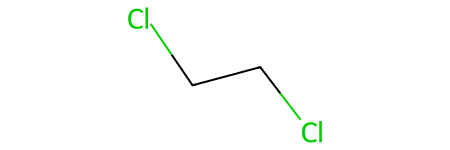

In [17]:
mol2 = Chem.SDMolSupplier('/home/cree/code/torsion-nagl/openff-nagl/examples/train-gnn-dihedrals/ClCCCl.sdf')
mol2[0]

In [18]:

# compute = ComputeSCoefficients()
# compute.compute_s_and_alpha(mol2[0], [3,2,1,0], [1,1,1,1])

In [19]:
test_molecule = Molecule.from_smiles("ClCCCCl")
test_molecule.generate_conformers(n_conformers=1)
#rdmol = Chem.SDMolSupplier('eclipse_ClCCCl.sdf', removeHs=False)[0]
#rdmol = Chem.MolFromSmiles('ClCCCl')

#test_molecule = Molecule.from_rdkit(rdmol)
reference_energies = get_central_bond_torsions(test_molecule, forcefield)
reference_energies

[0, 4.643307279258996, 0, 0, 8.798641905775721, 0, 0, 0, 0, 0]

In [20]:
# # assuming you have an instance of the molecule (e.g., `molecule`) and a pool object
# pool = InjectablePoolBondFeatures()

# # get the bond tensors by invoking the private method
# bond_features = pool._get_pooled_representations(test_molecule)

# # examine the bond tensors
# for i, bond_tensor in enumerate(bond_features):
#     print(f"Bond representation {i}:\n{bond_tensor}")

In [21]:
# switch to eval mode
training_model.model.eval()

with torch.no_grad():
    energies_1 = training_model.model.compute_properties(
        test_molecule,
        as_numpy=True
    )["energies"]

# switch back to training mode
training_model.model.train()

# compare charges
differences = reference_energies - energies_1
differences

inputs: tensor([[-0.3498],
        [-0.3432],
        [-0.3432],
        [-0.3498],
        [-0.3537],
        [-0.3537],
        [-0.3537],
        [-0.3537],
        [-0.3432],
        [-0.3432],
        [-0.3467],
        [-0.3467],
        [-0.3467],
        [-0.3467],
        [-0.3467],
        [-0.3467],
        [-0.3467],
        [-0.3467]])
c_ij: tensor([-0.3498, -0.3432, -0.3432, -0.3498, -0.3537, -0.3537, -0.3537, -0.3537,
        -0.3432, -0.3432, -0.3467, -0.3467, -0.3467, -0.3467, -0.3467, -0.3467,
        -0.3467, -0.3467])
torsion indices: tensor([[ 0,  0,  0,  1,  1,  1,  3,  3,  4,  4,  5,  5,  6,  6,  7,  7,  8,  8],
        [ 1,  1,  1,  2,  2,  2,  2,  2,  3,  3,  1,  1,  1,  1,  2,  2,  2,  2],
        [ 2,  2,  2,  3,  3,  3,  1,  1,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3],
        [ 3,  7,  8,  4,  9, 10,  5,  6,  7,  8,  7,  8,  7,  8,  9, 10,  9, 10]])
s: tensor([0.9592, 0.4101]), s_norm: 1.0432194471359253
a: 1.1668051481246948
s: tensor([0.9600, 0.4099]), s_n

/home/cree/code/torsion-nagl/openff-nagl/openff/nagl/utils/_tensors.py:214: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1718618105212/work/aten/src/ATen/native/Cross.cpp:62.)
  normal1 = torch.cross(ba, bc)
/home/cree/code/torsion-nagl/openff-nagl/openff/nagl/nn/_models.py:240: UserWarning: TODO: currently non-atom-wise properties are not properly handled!!! We just assume they are **strictly sequential**. In general we don't recommend using multiple molecules!!
  warnings.warn(


array([-0.04513083,  4.5999531 , -0.03701688, -0.03701688,  8.75528767,
       -0.03717402, -0.03717402, -0.04513087, -0.03701683, -0.03701683])

In [22]:
reference_energies

[0, 4.643307279258996, 0, 0, 8.798641905775721, 0, 0, 0, 0, 0]

In [23]:
energies_1

array([0.04513083, 0.04335418, 0.03701688, 0.03701688, 0.04335423,
       0.03717402, 0.03717402, 0.04513087, 0.03701683, 0.03701683])

### Training the model

We use Pytorch Lightning to train.

In [24]:
import pytorch_lightning as pl
from pytorch_lightning.callbacks import TQDMProgressBar
import torch
print(torch.cuda.is_available())

False


In [25]:
trainer = pl.Trainer(
    max_epochs=1,
    callbacks=[TQDMProgressBar()], # add progress bar
    accelerator="cpu"
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [26]:
datamodule = training_model.create_data_module(verbose=False)

Currently there are an abundance of warnings about conformer geometries being in angstrom.

In [27]:
trainer.fit(
    training_model,
    datamodule=datamodule,
)

Featurizing dataset: 0it [00:00, ?it/s]
Featurizing batch:   0%|                                | 0/640 [00:00<?, ?it/s]/home/cree/code/torsion-nagl/openff-nagl/openff/nagl/nn/_dataset.py:212: UserWarning: Conformer geometry is expected to be in angstrom
  warnings.warn(
/home/cree/code/torsion-nagl/openff-nagl/openff/nagl/nn/_dataset.py:212: UserWarning: Conformer geometry is expected to be in angstrom
  warnings.warn(
/home/cree/code/torsion-nagl/openff-nagl/openff/nagl/nn/_dataset.py:212: UserWarning: Conformer geometry is expected to be in angstrom
  warnings.warn(
/home/cree/code/torsion-nagl/openff-nagl/openff/nagl/nn/_dataset.py:212: UserWarning: Conformer geometry is expected to be in angstrom
  warnings.warn(
/home/cree/code/torsion-nagl/openff-nagl/openff/nagl/nn/_dataset.py:212: UserWarning: Conformer geometry is expected to be in angstrom
  warnings.warn(
/home/cree/code/torsion-nagl/openff-nagl/openff/nagl/nn/_dataset.py:212: UserWarning: Conformer geometry is expected to 

Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/home/cree/mambaforge/envs/nagl/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


inputs: tensor([[-0.3396],
        [-0.3404],
        [-0.3555],
        [-0.3649],
        [-0.3649],
        [-0.3649],
        [-0.3706],
        [-0.3706],
        [-0.3633],
        [-0.3396],
        [-0.3404],
        [-0.3555],
        [-0.3413],
        [-0.3413],
        [-0.3432],
        [-0.3590],
        [-0.3590],
        [-0.3590],
        [-0.3577],
        [-0.3577],
        [-0.3529],
        [-0.3580],
        [-0.3580],
        [-0.3572],
        [-0.3742],
        [-0.3742],
        [-0.3742],
        [-0.3595],
        [-0.3595],
        [-0.3607],
        [-0.3558],
        [-0.3558],
        [-0.3559],
        [-0.3558],
        [-0.3558],
        [-0.3559],
        [-0.3576],
        [-0.3576],
        [-0.3406],
        [-0.3406],
        [-0.3393],
        [-0.3406],
        [-0.3406],
        [-0.3393],
        [-0.3614],
        [-0.3614],
        [-0.3614],
        [-0.3614],
        [-0.3614],
        [-0.3614],
        [-0.3500],
        [-0.3500],
    

/home/cree/mambaforge/envs/nagl/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/home/cree/mambaforge/envs/nagl/lib/python3.12/site-packages/pytorch_lightning/loops/fit_loop.py:298: The number of training batches (7) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |                                               | 0/? [00:00<?, ?it/s]

inputs: tensor([[-0.3409],
        [-0.3211],
        [-0.3465],
        ...,
        [-0.3809],
        [-0.3809],
        [-0.3809]], grad_fn=<AddBackward0>)
c_ij: tensor([-0.3409, -0.3211, -0.3465,  ..., -0.3809, -0.3809, -0.3809],
       grad_fn=<SelectBackward0>)
torsion indices: tensor([[   0,    0,    1,  ..., 1890, 1891, 1891],
        [   1,    1,    3,  ..., 1889, 1889, 1889],
        [   3,    3,    4,  ..., 1892, 1892, 1892],
        [   4,    8,    5,  ..., 1894, 1893, 1894]])
s: tensor([0.0011, 0.0005], grad_fn=<SumBackward1>), s_norm: 0.0012044791365042329
a: 1.1468063592910767
s: tensor([0.0079, 0.0027], grad_fn=<SumBackward1>), s_norm: 0.00834388006478548
a: 1.2455201148986816
s: tensor([-0.0025, -0.0014], grad_fn=<SumBackward1>), s_norm: 0.0028925747610628605
a: -2.071484088897705
s: tensor([0.3422, 0.1264], grad_fn=<SumBackward1>), s_norm: 0.36474552750587463
a: 1.216981053352356
s: tensor([0.0030, 0.0015], grad_fn=<SumBackward1>), s_norm: 0.003357612993568182
a: 1.1

Validation: |                                             | 0/? [00:00<?, ?it/s]

inputs: tensor([[-0.0450],
        [-0.0389],
        [-0.0390],
        [-0.0547],
        [-0.0547],
        [-0.0547],
        [-0.0504],
        [-0.0504],
        [-0.0348],
        [-0.0450],
        [-0.0389],
        [-0.0390],
        [-0.0425],
        [-0.0425],
        [-0.0339],
        [-0.0482],
        [-0.0482],
        [-0.0482],
        [-0.0437],
        [-0.0437],
        [-0.0290],
        [-0.0349],
        [-0.0349],
        [-0.0196],
        [-0.0409],
        [-0.0409],
        [-0.0409],
        [-0.0391],
        [-0.0391],
        [-0.0424],
        [-0.0436],
        [-0.0436],
        [-0.0370],
        [-0.0436],
        [-0.0436],
        [-0.0370],
        [-0.0338],
        [-0.0338],
        [-0.0426],
        [-0.0426],
        [-0.0474],
        [-0.0426],
        [-0.0426],
        [-0.0474],
        [-0.0476],
        [-0.0476],
        [-0.0476],
        [-0.0476],
        [-0.0476],
        [-0.0476],
        [-0.0374],
        [-0.0374],
    

`Trainer.fit` stopped: `max_epochs=1` reached.


We can now check the energies again. They should have improved, especially if you used a larger dataset (note: results may vary with the small 50-molecule dataset this notebook has chosen to use, for reasons of speed).

Note, the energies are 

In [28]:
# switch to eval mode
training_model.model.eval()

with torch.no_grad():
    energies_2 = training_model.model.compute_properties(
        test_molecule,
        as_numpy=True
    )["energies"]



differences_after_training = reference_energies - energies_2
differences_after_training

inputs: tensor([[-0.0298],
        [-0.0449],
        [-0.0449],
        [-0.0298],
        [-0.0312],
        [-0.0312],
        [-0.0312],
        [-0.0312],
        [-0.0449],
        [-0.0449],
        [-0.0451],
        [-0.0451],
        [-0.0451],
        [-0.0451],
        [-0.0451],
        [-0.0451],
        [-0.0451],
        [-0.0451]])
c_ij: tensor([-0.0298, -0.0449, -0.0449, -0.0298, -0.0312, -0.0312, -0.0312, -0.0312,
        -0.0449, -0.0449, -0.0451, -0.0451, -0.0451, -0.0451, -0.0451, -0.0451,
        -0.0451, -0.0451])
torsion indices: tensor([[ 0,  0,  0,  1,  1,  1,  3,  3,  4,  4,  5,  5,  6,  6,  7,  7,  8,  8],
        [ 1,  1,  1,  2,  2,  2,  2,  2,  3,  3,  1,  1,  1,  1,  2,  2,  2,  2],
        [ 2,  2,  2,  3,  3,  3,  1,  1,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3],
        [ 3,  7,  8,  4,  9, 10,  5,  6,  7,  8,  7,  8,  7,  8,  9, 10,  9, 10]])
s: tensor([0.1103, 0.0472]), s_norm: 0.11995937675237656
a: 1.1668051481246948
s: tensor([0.1126, 0.0481]), s_

/home/cree/code/torsion-nagl/openff-nagl/openff/nagl/nn/_models.py:240: UserWarning: TODO: currently non-atom-wise properties are not properly handled!!! We just assume they are **strictly sequential**. In general we don't recommend using multiple molecules!!
  warnings.warn(


array([-1.09489346,  3.52257902, -1.09340811, -1.09340811,  7.67791365,
       -1.0728147 , -1.07281482, -1.09489346, -1.09340799, -1.09340799])

In [29]:
# original
sum(differences ** 2)

97.82694912889671

In [30]:
sum(differences_after_training ** 2)

80.84053205274114

In [31]:
energies_2

array([1.09489346, 1.12072825, 1.09340811, 1.09340811, 1.12072825,
       1.0728147 , 1.07281482, 1.09489346, 1.09340799, 1.09340799])

What's alpha?

In [32]:
training_model.model.compute_properties(
    test_molecule,
    as_numpy=True
)["alpha"]

inputs: tensor([[-0.0298],
        [-0.0449],
        [-0.0449],
        [-0.0298],
        [-0.0312],
        [-0.0312],
        [-0.0312],
        [-0.0312],
        [-0.0449],
        [-0.0449],
        [-0.0451],
        [-0.0451],
        [-0.0451],
        [-0.0451],
        [-0.0451],
        [-0.0451],
        [-0.0451],
        [-0.0451]], grad_fn=<AddBackward0>)
c_ij: tensor([-0.0298, -0.0449, -0.0449, -0.0298, -0.0312, -0.0312, -0.0312, -0.0312,
        -0.0449, -0.0449, -0.0451, -0.0451, -0.0451, -0.0451, -0.0451, -0.0451,
        -0.0451, -0.0451], grad_fn=<SelectBackward0>)
torsion indices: tensor([[ 0,  0,  0,  1,  1,  1,  3,  3,  4,  4,  5,  5,  6,  6,  7,  7,  8,  8],
        [ 1,  1,  1,  2,  2,  2,  2,  2,  3,  3,  1,  1,  1,  1,  2,  2,  2,  2],
        [ 2,  2,  2,  3,  3,  3,  1,  1,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3],
        [ 3,  7,  8,  4,  9, 10,  5,  6,  7,  8,  7,  8,  7,  8,  9, 10,  9, 10]])
s: tensor([0.1103, 0.0472], grad_fn=<SumBackward1>), s_norm

array([0.        , 1.16680515, 0.        , 0.        , 1.16725683,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [33]:
training_model.model.compute_properties(
    test_molecule,
    as_numpy=True
)["energies"]

inputs: tensor([[-0.0298],
        [-0.0449],
        [-0.0449],
        [-0.0298],
        [-0.0312],
        [-0.0312],
        [-0.0312],
        [-0.0312],
        [-0.0449],
        [-0.0449],
        [-0.0451],
        [-0.0451],
        [-0.0451],
        [-0.0451],
        [-0.0451],
        [-0.0451],
        [-0.0451],
        [-0.0451]], grad_fn=<AddBackward0>)
c_ij: tensor([-0.0298, -0.0449, -0.0449, -0.0298, -0.0312, -0.0312, -0.0312, -0.0312,
        -0.0449, -0.0449, -0.0451, -0.0451, -0.0451, -0.0451, -0.0451, -0.0451,
        -0.0451, -0.0451], grad_fn=<SelectBackward0>)
torsion indices: tensor([[ 0,  0,  0,  1,  1,  1,  3,  3,  4,  4,  5,  5,  6,  6,  7,  7,  8,  8],
        [ 1,  1,  1,  2,  2,  2,  2,  2,  3,  3,  1,  1,  1,  1,  2,  2,  2,  2],
        [ 2,  2,  2,  3,  3,  3,  1,  1,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3],
        [ 3,  7,  8,  4,  9, 10,  5,  6,  7,  8,  7,  8,  7,  8,  9, 10,  9, 10]])
s: tensor([0.1103, 0.0472], grad_fn=<SumBackward1>), s_norm

array([1.09489346, 1.12072825, 1.09340811, 1.09340811, 1.12072825,
       1.0728147 , 1.07281482, 1.09489346, 1.09340799, 1.09340799])

In [34]:
validation_table

pyarrow.Table
mapped_smiles: string
torsion_energies: list<element: double>
  child 0, element: double
conformer: list<element: double>
  child 0, element: double
----
mapped_smiles: [["[H:21][C:20]([H:22])([H:23])[N:19]([C:24]([H:25])([H:26])[H:27])[C:16]([H:17])([H:18])[C:13]([H:14])([H:15])[N+:10]([H:11])([H:12])[C:4]([H:5])([C:6]([Br:7])([Br:8])[Br:9])[N:2]([H:1])[H:3]","[H:22][C:21]([H:23])([H:24])[N+:19]([H:20])([C:25]([H:26])([H:27])[H:28])[C:16]([H:17])([H:18])[C:13]([H:14])([H:15])[N+:10]([H:11])([H:12])[C:4]([H:5])([C:6]([Br:7])([Br:8])[Br:9])[N:2]([H:1])[H:3]","[H:22][C:21]([H:23])([H:24])[N+:19]([H:20])([C:25]([H:26])([H:27])[H:28])[C:16]([H:17])([H:18])[C:13]([H:14])([H:15])[N+:10]([H:11])([H:12])[C:4]([H:5])([C:6]([Br:7])([Br:8])[Br:9])[N:2]([H:1])[H:3]","[H:22][C:21]([H:23])([H:24])[N+:19]([H:20])([C:25]([H:26])([H:27])[H:28])[C:16]([H:17])([H:18])[C:13]([H:14])([H:15])[N+:10]([H:11])([H:12])[C:4]([H:5])([C:6]([Br:7])([Br:8])[Br:9])[N:2]([H:1])[H:3]","[H:14][C:13]([H:15]